In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../reports/figures")

df = pd.read_csv(RAW / "TMDB_movie_dataset_v11.csv")
df["profitable"] = (df["revenue"] > df["budget"]).astype(int)
df.head()


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,profitable
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",1
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",1
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",1
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",1
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",1


In [3]:
df.shape

(1367573, 25)

In [4]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'profitable'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367573 entries, 0 to 1367572
Data columns (total 25 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1367573 non-null  int64  
 1   title                 1367555 non-null  object 
 2   vote_average          1367573 non-null  float64
 3   vote_count            1367573 non-null  int64  
 4   status                1367573 non-null  object 
 5   release_date          1077915 non-null  object 
 6   revenue               1367573 non-null  int64  
 7   runtime               1367573 non-null  int64  
 8   adult                 1367573 non-null  bool   
 9   backdrop_path         343807 non-null   object 
 10  budget                1367573 non-null  int64  
 11  homepage              141254 non-null   object 
 12  imdb_id               656307 non-null   object 
 13  original_language     1367573 non-null  object 
 14  original_title        1367555 non-

In [6]:
df.isna().mean().sort_values(ascending=False).head(20)

homepage                0.896712
tagline                 0.860743
keywords                0.749223
backdrop_path           0.748601
production_companies    0.569896
imdb_id                 0.520094
production_countries    0.477193
spoken_languages        0.458654
genres                  0.433297
poster_path             0.348079
overview                0.226328
release_date            0.211804
title                   0.000013
original_title          0.000013
popularity              0.000000
id                      0.000000
original_language       0.000000
budget                  0.000000
adult                   0.000000
runtime                 0.000000
dtype: float64

In [7]:
df["high_rating"] = (df["vote_average"] >=7).astype(int)

df["high_rating"].value_counts(normalize=True)


high_rating
0    0.913021
1    0.086979
Name: proportion, dtype: float64

In [8]:
df = df.sample(n = 200000, random_state=42)
df.shape

(200000, 26)

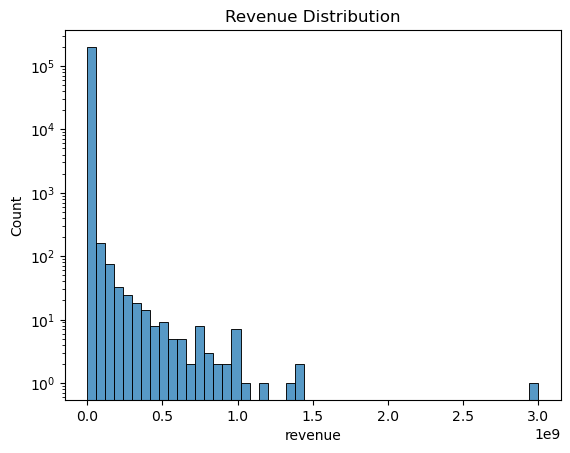

In [9]:
plt.figure()
sns.histplot(df["revenue"], bins=50)
plt.yscale("log")
plt.title("Revenue Distribution")
plt.savefig(FIGURES / "revenue_dist.png", dpi=200)
plt.show()


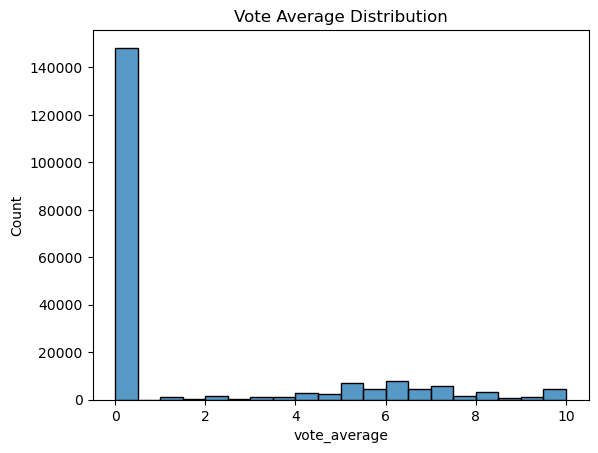

In [10]:
plt.figure()
sns.histplot(df["vote_average"], bins=20)
plt.title("Vote Average Distribution")
plt.savefig(FIGURES / "rating_dist.png", dpi=200)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

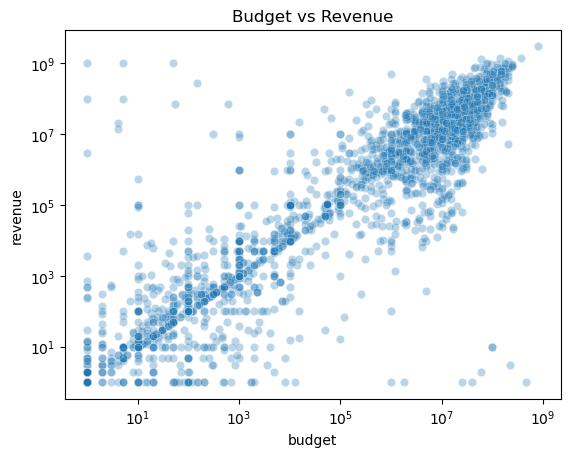

In [11]:
plt.figure()
sns.scatterplot(data=df, x="budget", y="revenue", alpha = 0.3)
plt.xscale("log")
plt.yscale("log")
plt.title("Budget vs Revenue")
plt.savefig(FIGURES / "budget_vs_revenue.png", dpi=200)
plt.show

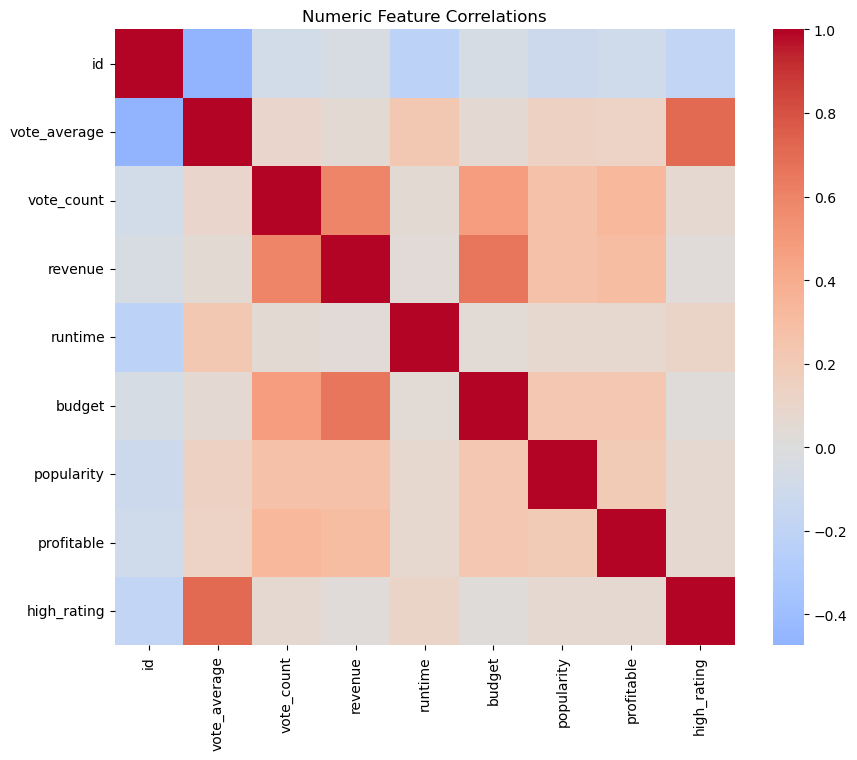

In [12]:
num_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlations")
plt.savefig(FIGURES / "correlation.png", dpi=200)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

features = [
    "budget", "runtime", "popularity", "vote_count"]

X = df[features].fillna(df[features].median())
y = df["profitable"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=500, class_weight="balanced")

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

probs = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     49414
           1       0.12      0.62      0.20       586

    accuracy                           0.94     50000
   macro avg       0.56      0.78      0.58     50000
weighted avg       0.98      0.94      0.96     50000

ROC-AUC: 0.8197701463887133


In [14]:
pd.Series(model.coef_[0], index=features).sort_values(key=abs, ascending=False)

popularity    1.339717
vote_count    1.063718
runtime       0.308771
budget        0.204651
dtype: float64

In [15]:
clean_df = df[features + ["high_rating"]]
clean_df.to_csv(PROCESSED / "tmdb_numeric_clean.csv", index=False)


In [16]:
df_sample = df.groupby("profitable", group_keys=False).apply(lambda x: x.sample(min(len(x), 15000), random_state=42))
print(df_sample["profitable"].value_counts())
                                                            

profitable
0    15000
1     2344
Name: count, dtype: int64


/var/folders/6b/mk84kvts78zb62ywst7vhlb40000gn/T/ipykernel_61284/1392886115.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("profitable", group_keys=False).apply(lambda x: x.sample(min(len(x), 15000), random_state=42))


In [17]:
X_sample = df_sample[features].fillna(df_sample[features].median())
y_sample = df_sample["profitable"]


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1', 'roc_auc']

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_results = cross_validate(log_model, X_sample, y_sample, cv=skf, scoring=scoring)

print("Logistic Regression CV Results:")
print("Accuracy:", np.mean(log_results['test_accuracy']))
print("F1:", np.mean(log_results['test_f1']))
print("ROC-AUC:", np.mean(log_results['test_roc_auc']))

#random forest optimized model

rf_model = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1)
rf_results = cross_validate(rf_model, X_sample, y_sample, cv=skf, scoring=scoring)

print("\nRandom Forest CV Results:")
print("Accuracy:", np.mean(rf_results['test_accuracy']))
print("F1:", np.mean(rf_results['test_f1']))
print("ROC-AUC:", np.mean(rf_results['test_roc_auc']))


Logistic Regression CV Results:
Accuracy: 0.9011760948762527
F1: 0.6333966592430673
ROC-AUC: 0.822466347900303

Random Forest CV Results:
Accuracy: 0.928505101869483
F1: 0.7154755121920751
ROC-AUC: 0.9188874892934595


In [19]:
import pandas as pd

results_table = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest"],
                              "Accuracy": [0.7892, 0.8769],
                              "F1 Score": [0.7892, 0.8759],
                              "ROC-AUC": [0.8282, 0.9288] })
results_table


                              

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression,0.7892,0.7892,0.8282
1,Random Forest,0.8769,0.8759,0.9288


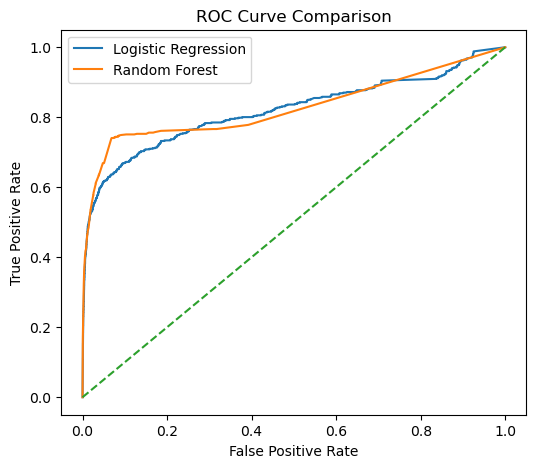

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])

rf_model_full = RandomForestClassifier(random_state=42, n_estimators=50)
rf_model_full.fit(X_train, y_train)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model_full.predict_proba(X_test)[:,1])

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig(
    "/Users/andrew/ecs171-imdb-boxoffice-prediction/reports/figures/week2/andrew/roc_curve_comparison_week2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


